# Домашнее задание Lite. Рекуррентные и одномерные свёрточные нейронные сети — **PyTorch**

**Задача**: классификация художественных текстов по авторам с помощью свёрточной нейросети.

**Стек**: PyTorch (вместо TensorFlow/Keras).

**План работы**:
1. Подготовка данных (6 писателей: Булгаков, Брэдберри, Стругацкие, Макс Фрай, Клиффорд Саймак, О. Генри).
2. Архитектура — аналог **Conv1D №1** (показала лучший результат).
3. Базовый эксперимент: `VOCAB_SIZE=20000, WIN_SIZE=1000, WIN_HOP=100`.
4. Эксперимент по `VOCAB_SIZE`: 5000, 10000, 40000 (`WIN_SIZE=1000, WIN_HOP=100`).
5. Эксперимент по `WIN_SIZE/WIN_HOP`: пары `(500, 50)` и `(2000, 200)` при `VOCAB_SIZE=20000`.
6. Сводная таблица и выводы.

**Особенности PyTorch-реализации**:
- Свой `Tokenizer` (вместо Keras-овского) — простой счётчик частот + словарь индексов.
- `nn.Conv1d` ожидает форму `(batch, channels, length)`, поэтому после `Embedding` нужен `permute(0, 2, 1)`.
- Цикл обучения пишется руками: `optimizer.zero_grad() → forward → loss → backward → step`.
- Чтобы код повторял Keras-овский `SpatialDropout1D`, мы используем `nn.Dropout2d` поверх эмбеддингов с временной осью как «каналом».

## 1. Подготовка

In [ ]:
# Работа с массивами
import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Метрики
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов
import gdown

# Прочее
import os
import time
import re
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display

%matplotlib inline

# Устройство для обучения
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Используем устройство:', DEVICE)

# Фиксируем сиды для воспроизводимости
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Используем устройство: cuda


In [ ]:
# Загрузим датасет
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [ ]:
# Распакуем архив
!unzip -qo writers.zip -d writers/

In [ ]:
# Константы для разбора имён файлов
FILE_DIR  = 'writers'
SIG_TRAIN = 'обучающая'
SIG_TEST  = 'тестовая'

In [ ]:
# Загрузка текстов по классам
CLASS_LIST = []
text_train = []
text_test  = []

file_list = os.listdir(FILE_DIR)
for file_name in file_list:
    m = re.match(r'\((.+)\) (\S+)_', file_name)
    if not m:
        continue
    class_name = m[1]
    subset_name = m[2].lower()

    is_train = SIG_TRAIN in subset_name
    is_test  = SIG_TEST  in subset_name
    if not (is_train or is_test):
        continue

    if class_name not in CLASS_LIST:
        print(f'Добавление класса "{class_name}"')
        CLASS_LIST.append(class_name)
        text_train.append('')
        text_test.append('')

    cls = CLASS_LIST.index(class_name)
    print(f'  → файл "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка')

    with open(f'{FILE_DIR}/{file_name}', 'r', encoding='utf-8') as f:
        text = f.read()
    subset = text_train if is_train else text_test
    subset[cls] += ' ' + text.replace('\n', ' ')

CLASS_COUNT = len(CLASS_LIST)
print(f'\nКлассы: {CLASS_LIST}')
print(f'Количество классов: {CLASS_COUNT}')

Добавление класса "Макс Фрай"
  → файл "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка
Добавление класса "Рэй Брэдберри"
  → файл "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка
Добавление класса "Клиффорд_Саймак"
  → файл "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка
Добавление класса "О. Генри"
  → файл "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка
Добавление класса "Булгаков"
  → файл "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка
  → файл "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка
  → файл "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка
  → файл "(Рэй Брэдберри) Тестовая_8 вместе.txt" в класс "Рэй Брэдберри", тестовая выборка
  → файл "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка
Добавление класса "Стругацкие"
  → файл "(Стругацкие) Тестовая

In [ ]:
# Контекстный менеджер для измерения времени
class timex:
    def __enter__(self):
        self.t = time.time()
        return self
    def __exit__(self, type, value, traceback):
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

## 2. Свой токенизатор на PyTorch

В Keras был готовый класс `Tokenizer`. Здесь напишем свой — он делает то же самое:
1. Чистит текст от пунктуации и приводит к нижнему регистру.
2. Считает частоты слов.
3. Оставляет топ-`VOCAB_SIZE` самых частых.
4. Резервирует индекс `0` под padding и индекс `1` под OOV-токен (неизвестные слова).
5. Преобразует тексты в последовательности индексов.

In [ ]:
# Простой токенизатор-аналог keras.Tokenizer
class SimpleTokenizer:
    def __init__(self, num_words, oov_token='<OOV>'):
        self.num_words = num_words
        self.oov_token = oov_token
        self.word_index = {}                  # слово → индекс
        # Регекс для удаления пунктуации (как filters в Keras)
        self.filters_re = re.compile(
            r'[!"#$%&()*+,\-–—./…:;<=>?@\[\\\]^_`{|}~«»\t\n\xa0\ufeff]'
        )

    def _clean(self, text):
        text = self.filters_re.sub(' ', text.lower())
        return text.split()

    def fit_on_texts(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(self._clean(text))
        # Резервируем 0 под padding, 1 под OOV
        # Берём top (num_words - 2) самых частых слов — на остальные индексы
        most_common = counter.most_common(self.num_words - 2)
        self.word_index = {self.oov_token: 1}
        for i, (word, _) in enumerate(most_common, start=2):
            self.word_index[word] = i

    def texts_to_sequences(self, texts):
        oov_idx = self.word_index[self.oov_token]
        result = []
        for text in texts:
            seq = [self.word_index.get(w, oov_idx) for w in self._clean(text)]
            result.append(seq)
        return result

## 3. Универсальные функции для подготовки и обучения

In [ ]:
# Разбиение скользящим окном
def split_sequence(sequence, win_size, hop):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


def vectorize_sequence(seq_list, win_size, hop):
    """Возвращает x (np.int64) и y (np.int64) — class indices."""
    class_count = len(seq_list)
    x, y = [], []
    for cls in range(class_count):
        vectors = split_sequence(seq_list[cls], win_size, hop)
        x += vectors
        y += [cls] * len(vectors)
    # int64 — стандартный тип для embedding и CrossEntropyLoss в PyTorch
    return np.array(x, dtype=np.int64), np.array(y, dtype=np.int64)


def prepare_dataset(vocab_size, win_size, win_hop):
    print(f'\nVOCAB_SIZE={vocab_size}, WIN_SIZE={win_size}, WIN_HOP={win_hop}')

    tokenizer = SimpleTokenizer(num_words=vocab_size)
    tokenizer.fit_on_texts(text_train)

    seq_train = tokenizer.texts_to_sequences(text_train)
    seq_test  = tokenizer.texts_to_sequences(text_test)

    x_train, y_train = vectorize_sequence(seq_train, win_size, win_hop)
    x_test,  y_test  = vectorize_sequence(seq_test,  win_size, win_hop)

    print(f'x_train: {x_train.shape}, x_test: {x_test.shape}')
    return x_train, y_train, x_test, y_test

### Архитектура — аналог Conv1D №1

В Keras-версии было:
```
Embedding(VOCAB_SIZE, 10, input_length=WIN_SIZE)
SpatialDropout1D(0.2)
BatchNormalization()
Conv1D(20, 5, activation='relu', padding='same')
Conv1D(20, 5, activation='relu')
MaxPooling1D(2)
Dropout(0.2)
BatchNormalization()
Flatten()
Dense(CLASS_COUNT, activation='softmax')
```

В PyTorch — то же, с несколькими тонкостями:
- `nn.Conv1d` ждёт `(batch, channels, length)`, а после `Embedding` форма `(batch, length, embed_dim)` — поэтому делаем `permute(0, 2, 1)`.
- Аналог `SpatialDropout1D` — `nn.Dropout2d`, применённый к тензору с эмбеддингами как к «каналам».
- `padding='same'` для размера ядра 5 → `padding=2`. Без `same` (второй Conv) — длина уменьшается на `kernel-1=4`.
- В PyTorch `softmax` обычно не пишут в модели — `nn.CrossEntropyLoss` сам применяет `log_softmax` к логитам. Это эффективнее и численно устойчивее.

In [ ]:
class Conv1DTextClassifier(nn.Module):
    def __init__(self, vocab_size, win_size, num_classes, embed_dim=10):
        super().__init__()

        # Embedding (padding_idx=0 — нулевой индекс не обновляется при обучении)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # SpatialDropout1D-аналог: дропаем целые признаковые карты по временной оси
        self.spatial_dropout = nn.Dropout2d(0.2)
        # BatchNorm по эмбеддинг-признакам
        self.bn1 = nn.BatchNorm1d(embed_dim)

        # Conv1: padding='same' для kernel=5 → padding=2; длина не меняется
        self.conv1 = nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        # Conv2: без padding → длина уменьшается на 4
        self.conv2 = nn.Conv1d(20, 20, kernel_size=5)

        self.maxpool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.2)
        self.bn2 = nn.BatchNorm1d(20)

        # Считаем размер на входе классификатора:
        # WIN_SIZE → conv1 (same) → WIN_SIZE → conv2 → WIN_SIZE-4 → maxpool/2 → (WIN_SIZE-4)//2
        self.flat_dim = 20 * ((win_size - 4) // 2)
        self.fc = nn.Linear(self.flat_dim, num_classes)

    def forward(self, x):
        # x: (batch, win_size), индексы слов
        x = self.embedding(x)                    # (batch, win, embed)
        # Spatial Dropout1D: применяем 2D-дропаут к (batch, embed, win, 1) — обнуляются целые embed-каналы
        x = x.permute(0, 2, 1).unsqueeze(-1)     # (batch, embed, win, 1)
        x = self.spatial_dropout(x).squeeze(-1)  # (batch, embed, win)
        x = self.bn1(x)
        x = F.relu(self.conv1(x))                # (batch, 20, win)
        x = F.relu(self.conv2(x))                # (batch, 20, win-4)
        x = self.maxpool(x)                      # (batch, 20, (win-4)//2)
        x = self.dropout(x)
        x = self.bn2(x)
        x = x.flatten(1)                         # (batch, 20*((win-4)//2))
        x = self.fc(x)                           # (batch, num_classes) — логиты
        return x


def build_best_model(vocab_size, win_size):
    return Conv1DTextClassifier(vocab_size=vocab_size,
                                win_size=win_size,
                                num_classes=CLASS_COUNT,
                                embed_dim=10).to(DEVICE)

### Цикл обучения и оценки

In [ ]:
def train_and_evaluate(model, x_train, y_train, x_test, y_test,
                       title='', epochs=30, batch_size=200, lr=1e-3):
    # DataLoader-ы
    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)),
        batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        TensorDataset(torch.from_numpy(x_test), torch.from_numpy(y_test)),
        batch_size=batch_size, shuffle=False
    )

    # RMSprop(Keras-овский 'rmsprop' с дефолтными параметрами)
    optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        #  train
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss   += loss.item() * xb.size(0)
            train_correct += (logits.argmax(1) == yb).sum().item()
            train_total   += xb.size(0)

        #  val
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss   += loss.item() * xb.size(0)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total   += xb.size(0)

        tr_loss = train_loss / train_total
        tr_acc  = train_correct / train_total
        va_loss = val_loss / val_total
        va_acc  = val_correct / val_total

        history['loss'].append(tr_loss)
        history['accuracy'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_accuracy'].append(va_acc)

        print(f'Epoch {epoch+1:>2}/{epochs} | '
              f'loss: {tr_loss:.4f} acc: {tr_acc:.4f} | '
              f'val_loss: {va_loss:.4f} val_acc: {va_acc:.4f}')

    # Графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle(f'Процесс обучения: {title}')
    ax1.plot(history['accuracy'],     label='train accuracy')
    ax1.plot(history['val_accuracy'], label='val accuracy')
    ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True)
    ax2.plot(history['loss'],     label='train loss')
    ax2.plot(history['val_loss'], label='val loss')
    ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True)
    plt.show()

    # Матрица ошибок
    model.eval()
    all_preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(DEVICE)
            preds = model(xb).argmax(1).cpu().numpy()
            all_preds.append(preds)
    y_pred = np.concatenate(all_preds)

    cm = confusion_matrix(y_test, y_pred, normalize='true')
    cm = np.around(cm, 3)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(f'Матрица ошибок: {title}', fontsize=14)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()
    plt.xlabel('Предсказанные классы'); plt.ylabel('Верные классы')
    fig.autofmt_xdate(rotation=45)
    plt.show()

    accuracy = cm.diagonal().mean()
    print(f'\n--- Результат "{title}" ---')
    for cls in range(CLASS_COUNT):
        cls_pred = np.argmax(cm[cls])
        msg = 'ВЕРНО' if cls_pred == cls else 'НЕВЕРНО'
        print(f'  Класс: {CLASS_LIST[cls]:<20} {100*cm[cls, cls_pred]:3.0f}% → {CLASS_LIST[cls_pred]:<20} - {msg}')
    print(f'\nСредняя точность распознавания: {100*accuracy:.1f}%')

    return {
        'title': title,
        'mean_acc': accuracy,
        'best_val_acc': max(history['val_accuracy']),
        'final_val_acc': history['val_accuracy'][-1]
    }

## 4. Эксперимент 1 — базовая конфигурация

`VOCAB_SIZE = 20000`, `WIN_SIZE = 1000`, `WIN_HOP = 100` — отправная точка

In [ ]:
# Сборщик результатов
results = []


VOCAB_SIZE=20000, WIN_SIZE=1000, WIN_HOP=100
x_train: (17640, 1000), x_test: (6686, 1000)
Epoch  1/30 | loss: 1.9421 acc: 0.3838 | val_loss: 2.0768 val_acc: 0.3286
Epoch  2/30 | loss: 1.0549 acc: 0.6209 | val_loss: 2.3689 val_acc: 0.3174
Epoch  3/30 | loss: 0.7020 acc: 0.7442 | val_loss: 1.9608 val_acc: 0.4322
Epoch  4/30 | loss: 0.5123 acc: 0.8155 | val_loss: 2.9171 val_acc: 0.3240
Epoch  5/30 | loss: 0.3777 acc: 0.8616 | val_loss: 1.9688 val_acc: 0.4728
Epoch  6/30 | loss: 0.2975 acc: 0.8922 | val_loss: 3.4748 val_acc: 0.3136
Epoch  7/30 | loss: 0.2368 acc: 0.9164 | val_loss: 2.5815 val_acc: 0.4119
Epoch  8/30 | loss: 0.1908 acc: 0.9320 | val_loss: 2.5399 val_acc: 0.4445
Epoch  9/30 | loss: 0.1576 acc: 0.9439 | val_loss: 2.2437 val_acc: 0.4798
Epoch 10/30 | loss: 0.1360 acc: 0.9517 | val_loss: 2.7035 val_acc: 0.4640
Epoch 11/30 | loss: 0.1195 acc: 0.9569 | val_loss: 2.1546 val_acc: 0.5277
Epoch 12/30 | loss: 0.1025 acc: 0.9645 | val_loss: 3.1540 val_acc: 0.4475
Epoch 13/30 | loss: 0

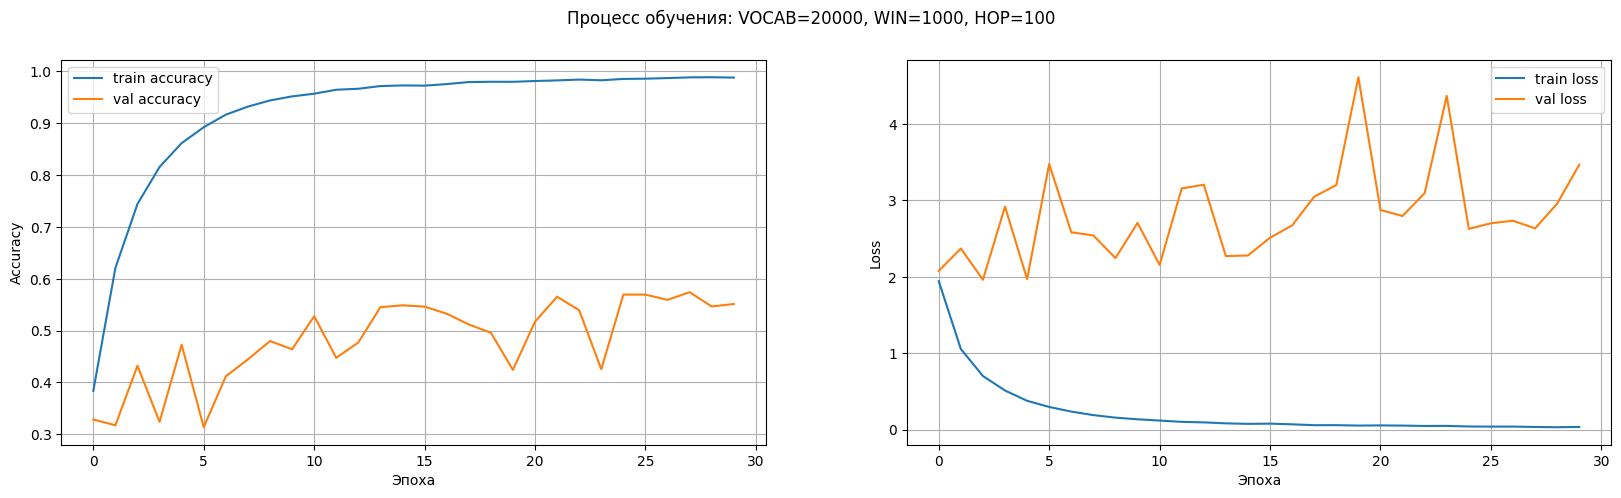

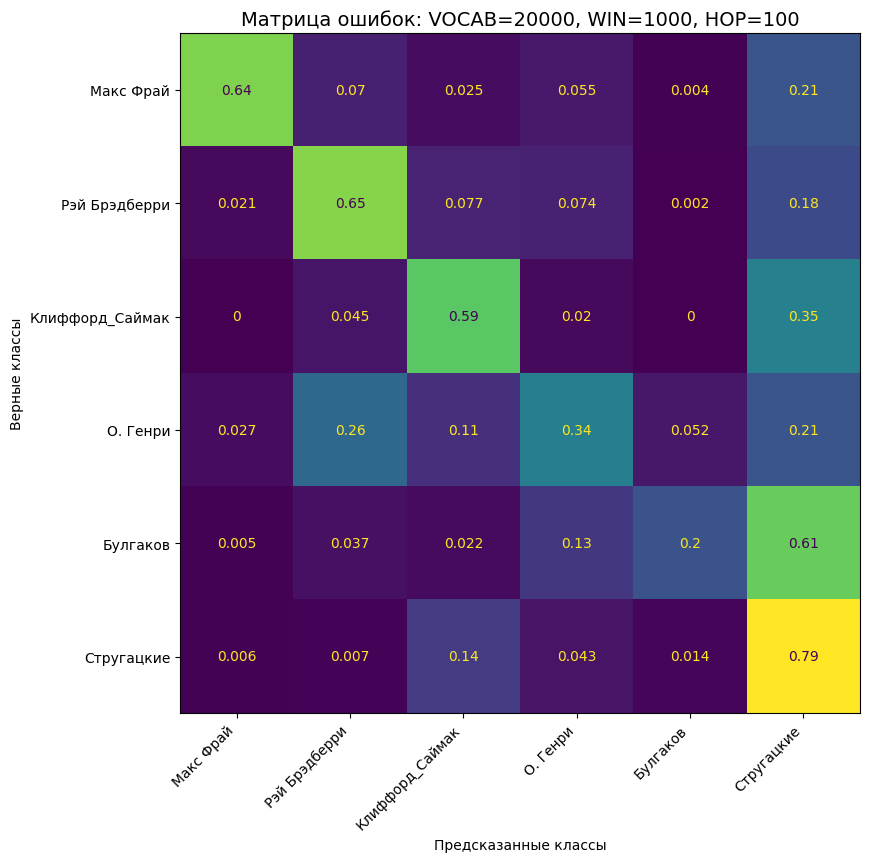


--- Результат "VOCAB=20000, WIN=1000, HOP=100" ---
  Класс: Макс Фрай             64% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         65% → Рэй Брэдберри        - ВЕРНО
  Класс: Клиффорд_Саймак       59% → Клиффорд_Саймак      - ВЕРНО
  Класс: О. Генри              34% → О. Генри             - ВЕРНО
  Класс: Булгаков              61% → Стругацкие           - НЕВЕРНО
  Класс: Стругацкие            79% → Стругацкие           - ВЕРНО

Средняя точность распознавания: 53.4%


In [ ]:
# Эксперимент 1: VOCAB=20000, WIN=1000, HOP=100
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=20000, win_size=1000, win_hop=100)
torch.manual_seed(SEED)   # фиксируем инициализацию для каждой новой модели
model = build_best_model(vocab_size=20000, win_size=1000)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=20000, WIN=1000, HOP=100', epochs=30)
res['vocab'] = 20000; res['win'] = 1000; res['hop'] = 100
results.append(res)

## 5. Эксперимент по влиянию `VOCAB_SIZE`

`WIN_SIZE = 1000`, `WIN_HOP = 100` — фиксированы.


VOCAB_SIZE=5000, WIN_SIZE=1000, WIN_HOP=100
x_train: (17640, 1000), x_test: (6686, 1000)
Epoch  1/30 | loss: 1.9345 acc: 0.3817 | val_loss: 2.6251 val_acc: 0.2653
Epoch  2/30 | loss: 1.0817 acc: 0.6048 | val_loss: 2.3797 val_acc: 0.3389
Epoch  3/30 | loss: 0.7816 acc: 0.7148 | val_loss: 2.5817 val_acc: 0.3108
Epoch  4/30 | loss: 0.5782 acc: 0.7880 | val_loss: 2.1999 val_acc: 0.4291
Epoch  5/30 | loss: 0.4494 acc: 0.8361 | val_loss: 2.6030 val_acc: 0.3590
Epoch  6/30 | loss: 0.3618 acc: 0.8702 | val_loss: 3.3116 val_acc: 0.2924
Epoch  7/30 | loss: 0.3005 acc: 0.8923 | val_loss: 2.1058 val_acc: 0.4485
Epoch  8/30 | loss: 0.2457 acc: 0.9150 | val_loss: 2.2018 val_acc: 0.4511
Epoch  9/30 | loss: 0.2137 acc: 0.9253 | val_loss: 1.9654 val_acc: 0.4994
Epoch 10/30 | loss: 0.1755 acc: 0.9372 | val_loss: 2.2966 val_acc: 0.4933
Epoch 11/30 | loss: 0.1608 acc: 0.9423 | val_loss: 2.5292 val_acc: 0.5227
Epoch 12/30 | loss: 0.1481 acc: 0.9489 | val_loss: 2.2478 val_acc: 0.4940
Epoch 13/30 | loss: 0.

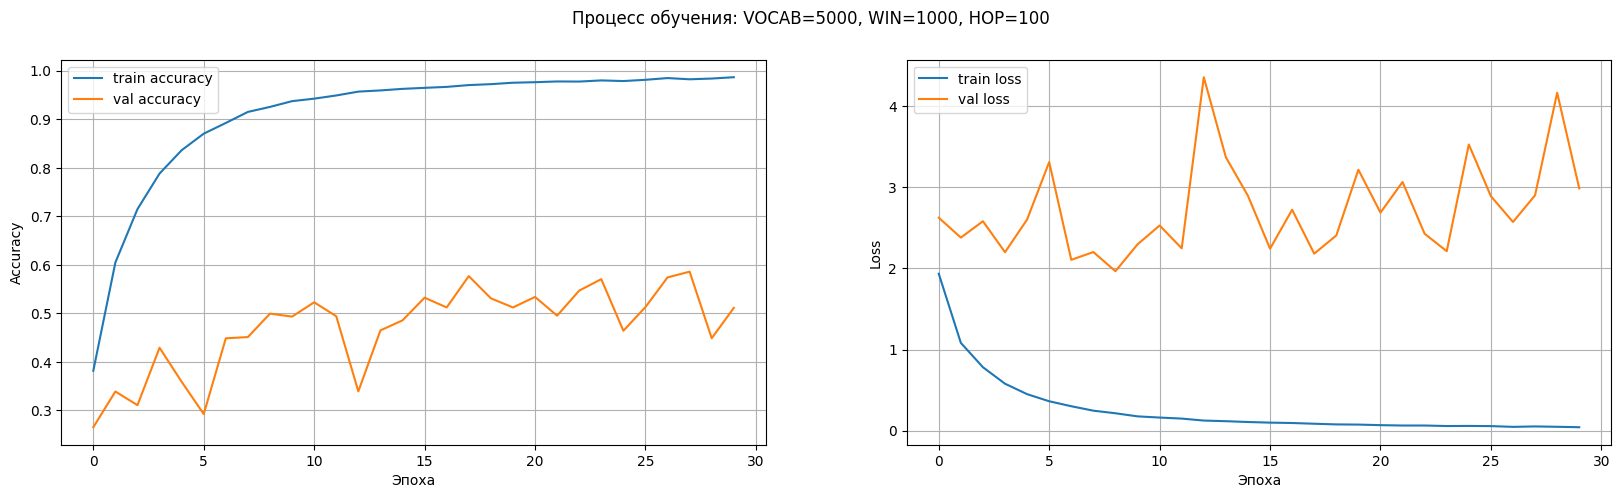

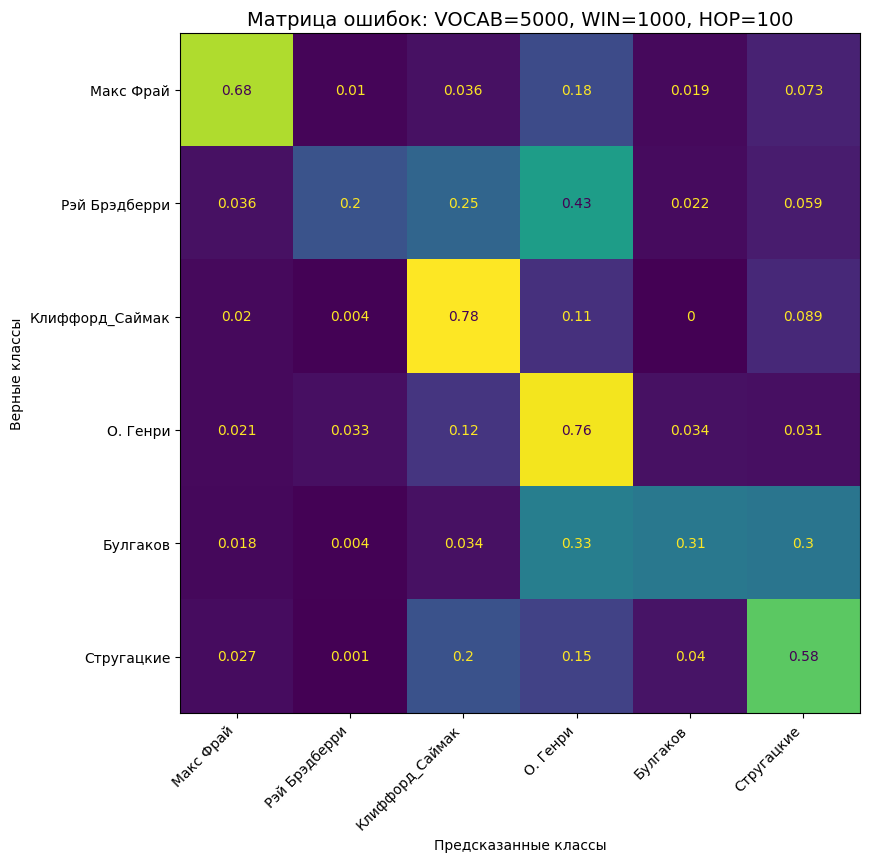


--- Результат "VOCAB=5000, WIN=1000, HOP=100" ---
  Класс: Макс Фрай             68% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         43% → О. Генри             - НЕВЕРНО
  Класс: Клиффорд_Саймак       78% → Клиффорд_Саймак      - ВЕРНО
  Класс: О. Генри              76% → О. Генри             - ВЕРНО
  Класс: Булгаков              33% → О. Генри             - НЕВЕРНО
  Класс: Стругацкие            58% → Стругацкие           - ВЕРНО

Средняя точность распознавания: 55.2%


In [ ]:
#  Эксперимент 2: VOCAB=5000
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=5000, win_size=1000, win_hop=100)
torch.manual_seed(SEED)
model = build_best_model(vocab_size=5000, win_size=1000)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=5000, WIN=1000, HOP=100', epochs=30)
res['vocab'] = 5000; res['win'] = 1000; res['hop'] = 100
results.append(res)


VOCAB_SIZE=10000, WIN_SIZE=1000, WIN_HOP=100
x_train: (17640, 1000), x_test: (6686, 1000)
Epoch  1/30 | loss: 1.9323 acc: 0.3734 | val_loss: 2.2987 val_acc: 0.3343
Epoch  2/30 | loss: 1.1106 acc: 0.5916 | val_loss: 2.1882 val_acc: 0.3449
Epoch  3/30 | loss: 0.7842 acc: 0.7087 | val_loss: 2.5854 val_acc: 0.3645
Epoch  4/30 | loss: 0.5710 acc: 0.7895 | val_loss: 2.0904 val_acc: 0.4125
Epoch  5/30 | loss: 0.4497 acc: 0.8392 | val_loss: 1.9768 val_acc: 0.4204
Epoch  6/30 | loss: 0.3432 acc: 0.8770 | val_loss: 2.4983 val_acc: 0.4176
Epoch  7/30 | loss: 0.2807 acc: 0.8981 | val_loss: 2.4834 val_acc: 0.4158
Epoch  8/30 | loss: 0.2254 acc: 0.9197 | val_loss: 2.4678 val_acc: 0.4456
Epoch  9/30 | loss: 0.1817 acc: 0.9336 | val_loss: 2.2815 val_acc: 0.4610
Epoch 10/30 | loss: 0.1688 acc: 0.9400 | val_loss: 2.5357 val_acc: 0.4646
Epoch 11/30 | loss: 0.1431 acc: 0.9515 | val_loss: 3.4133 val_acc: 0.4186
Epoch 12/30 | loss: 0.1228 acc: 0.9563 | val_loss: 2.8704 val_acc: 0.4517
Epoch 13/30 | loss: 0

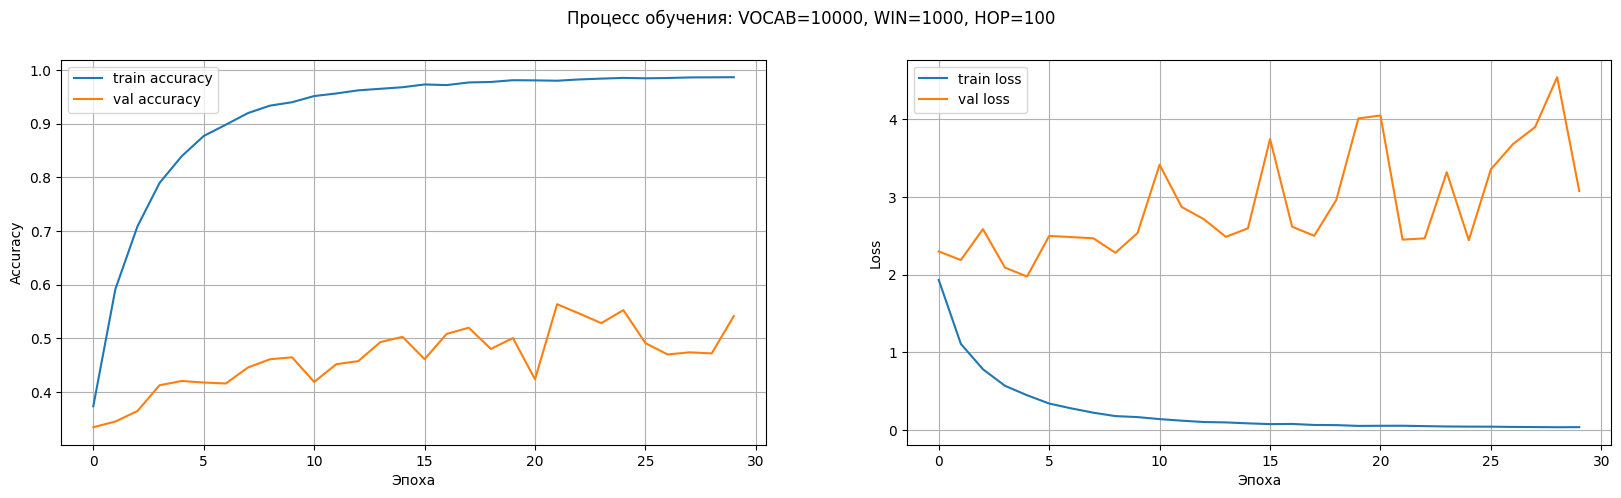

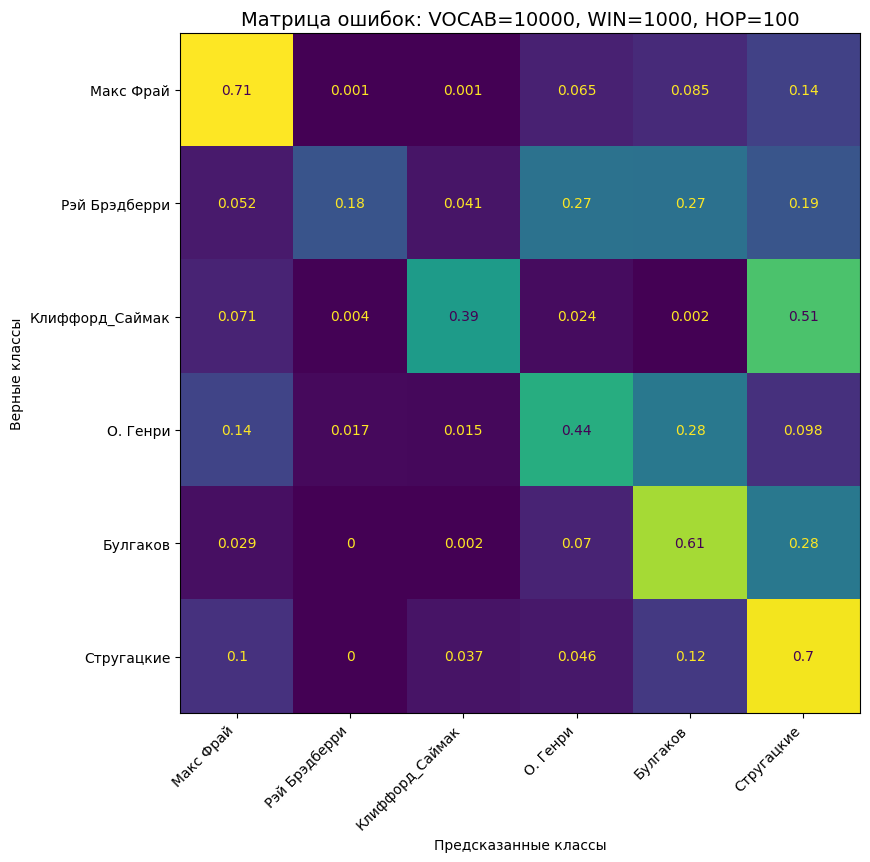


--- Результат "VOCAB=10000, WIN=1000, HOP=100" ---
  Класс: Макс Фрай             71% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         27% → О. Генри             - НЕВЕРНО
  Класс: Клиффорд_Саймак       51% → Стругацкие           - НЕВЕРНО
  Класс: О. Генри              44% → О. Генри             - ВЕРНО
  Класс: Булгаков              62% → Булгаков             - ВЕРНО
  Класс: Стругацкие            70% → Стругацкие           - ВЕРНО

Средняя точность распознавания: 50.7%


In [ ]:
#  Эксперимент 3: VOCAB=10000
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=10000, win_size=1000, win_hop=100)
torch.manual_seed(SEED)
model = build_best_model(vocab_size=10000, win_size=1000)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=10000, WIN=1000, HOP=100', epochs=30)
res['vocab'] = 10000; res['win'] = 1000; res['hop'] = 100
results.append(res)


VOCAB_SIZE=40000, WIN_SIZE=1000, WIN_HOP=100
x_train: (17640, 1000), x_test: (6686, 1000)
Epoch  1/30 | loss: 1.8993 acc: 0.3949 | val_loss: 2.6768 val_acc: 0.2908
Epoch  2/30 | loss: 0.9586 acc: 0.6550 | val_loss: 2.6869 val_acc: 0.3192
Epoch  3/30 | loss: 0.6166 acc: 0.7738 | val_loss: 2.3472 val_acc: 0.3829
Epoch  4/30 | loss: 0.4062 acc: 0.8523 | val_loss: 1.9515 val_acc: 0.4587
Epoch  5/30 | loss: 0.2931 acc: 0.8967 | val_loss: 3.1428 val_acc: 0.3962
Epoch  6/30 | loss: 0.1991 acc: 0.9296 | val_loss: 2.3527 val_acc: 0.4472
Epoch  7/30 | loss: 0.1627 acc: 0.9408 | val_loss: 2.9818 val_acc: 0.3800
Epoch  8/30 | loss: 0.1311 acc: 0.9545 | val_loss: 2.2095 val_acc: 0.4940
Epoch  9/30 | loss: 0.1010 acc: 0.9643 | val_loss: 2.0371 val_acc: 0.5317
Epoch 10/30 | loss: 0.0924 acc: 0.9673 | val_loss: 3.1379 val_acc: 0.4607
Epoch 11/30 | loss: 0.0774 acc: 0.9724 | val_loss: 2.8860 val_acc: 0.4638
Epoch 12/30 | loss: 0.0708 acc: 0.9747 | val_loss: 3.0238 val_acc: 0.5007
Epoch 13/30 | loss: 0

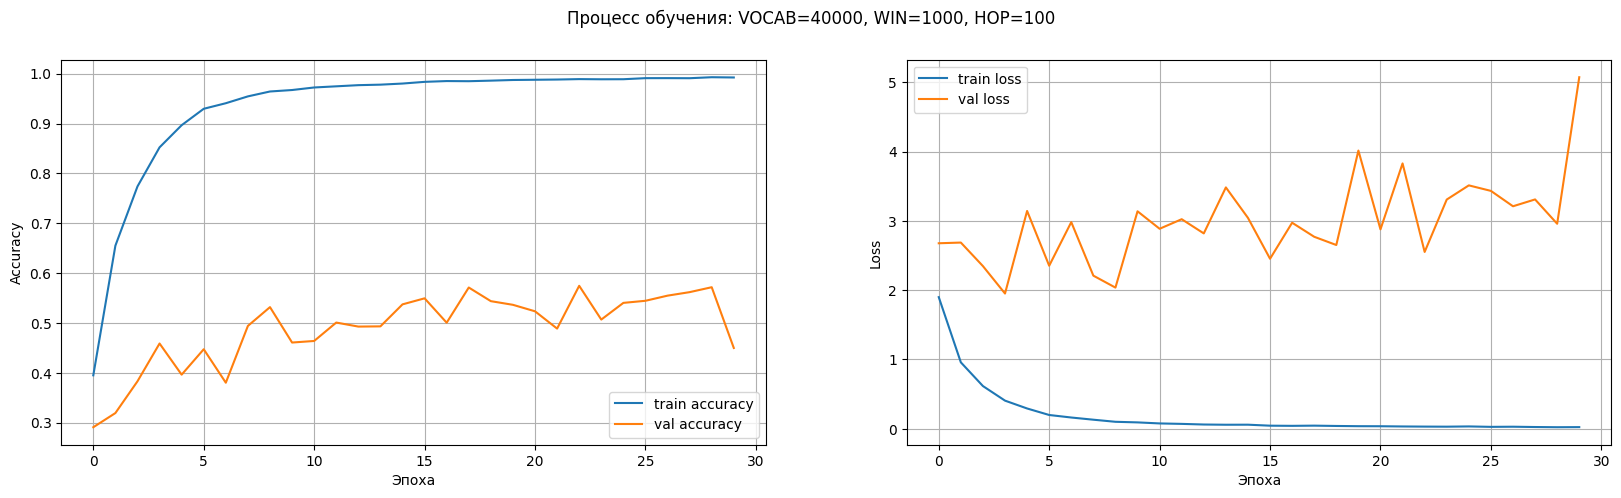

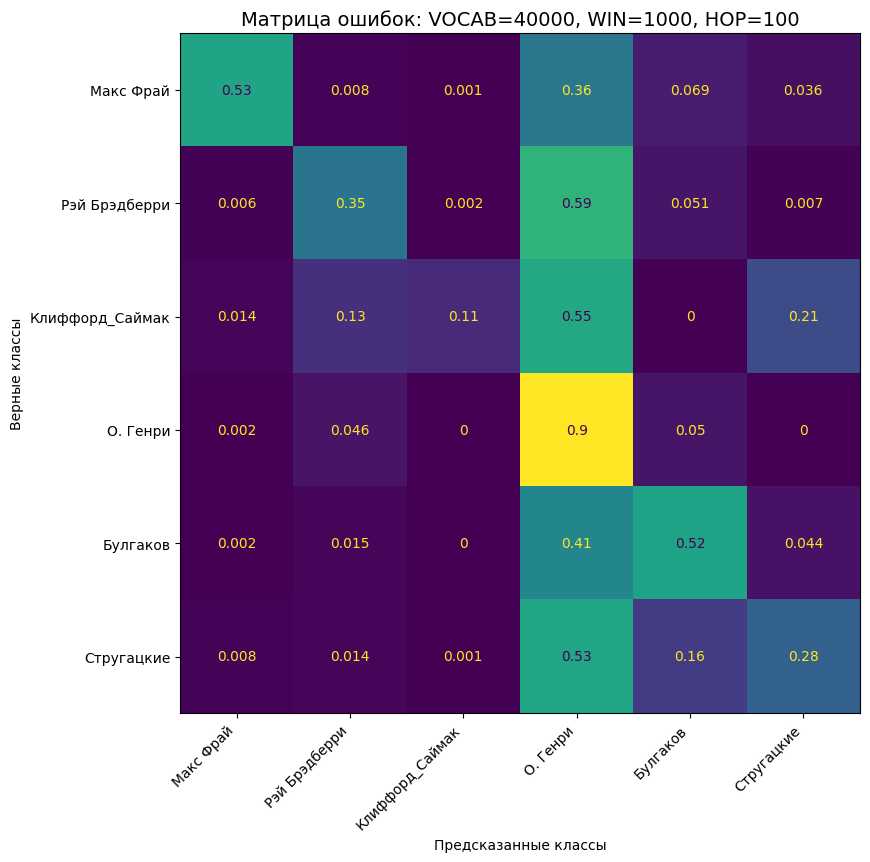


--- Результат "VOCAB=40000, WIN=1000, HOP=100" ---
  Класс: Макс Фрай             53% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         59% → О. Генри             - НЕВЕРНО
  Класс: Клиффорд_Саймак       55% → О. Генри             - НЕВЕРНО
  Класс: О. Генри              90% → О. Генри             - ВЕРНО
  Класс: Булгаков              52% → Булгаков             - ВЕРНО
  Класс: Стругацкие            53% → О. Генри             - НЕВЕРНО

Средняя точность распознавания: 44.8%


In [ ]:
#  Эксперимент 4: VOCAB=40000
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=40000, win_size=1000, win_hop=100)
torch.manual_seed(SEED)
model = build_best_model(vocab_size=40000, win_size=1000)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=40000, WIN=1000, HOP=100', epochs=30)
res['vocab'] = 40000; res['win'] = 1000; res['hop'] = 100
results.append(res)

## 6. Эксперимент по влиянию `WIN_SIZE`/`WIN_HOP`

`VOCAB_SIZE = 20000` — фиксирован.


VOCAB_SIZE=20000, WIN_SIZE=500, WIN_HOP=50
x_train: (35336, 500), x_test: (13427, 500)
Epoch  1/30 | loss: 1.6058 acc: 0.4045 | val_loss: 1.9751 val_acc: 0.3145
Epoch  2/30 | loss: 1.0342 acc: 0.6123 | val_loss: 2.0032 val_acc: 0.3978
Epoch  3/30 | loss: 0.7084 acc: 0.7396 | val_loss: 1.9348 val_acc: 0.4139
Epoch  4/30 | loss: 0.4946 acc: 0.8203 | val_loss: 1.7015 val_acc: 0.4856
Epoch  5/30 | loss: 0.3525 acc: 0.8720 | val_loss: 1.7790 val_acc: 0.4960
Epoch  6/30 | loss: 0.2587 acc: 0.9065 | val_loss: 2.1081 val_acc: 0.4851
Epoch  7/30 | loss: 0.1899 acc: 0.9313 | val_loss: 1.7110 val_acc: 0.5658
Epoch  8/30 | loss: 0.1450 acc: 0.9480 | val_loss: 1.9329 val_acc: 0.5451
Epoch  9/30 | loss: 0.1179 acc: 0.9583 | val_loss: 1.8618 val_acc: 0.5567
Epoch 10/30 | loss: 0.0952 acc: 0.9654 | val_loss: 2.0409 val_acc: 0.5693
Epoch 11/30 | loss: 0.0800 acc: 0.9699 | val_loss: 3.0080 val_acc: 0.4667
Epoch 12/30 | loss: 0.0715 acc: 0.9749 | val_loss: 2.1397 val_acc: 0.5603
Epoch 13/30 | loss: 0.06

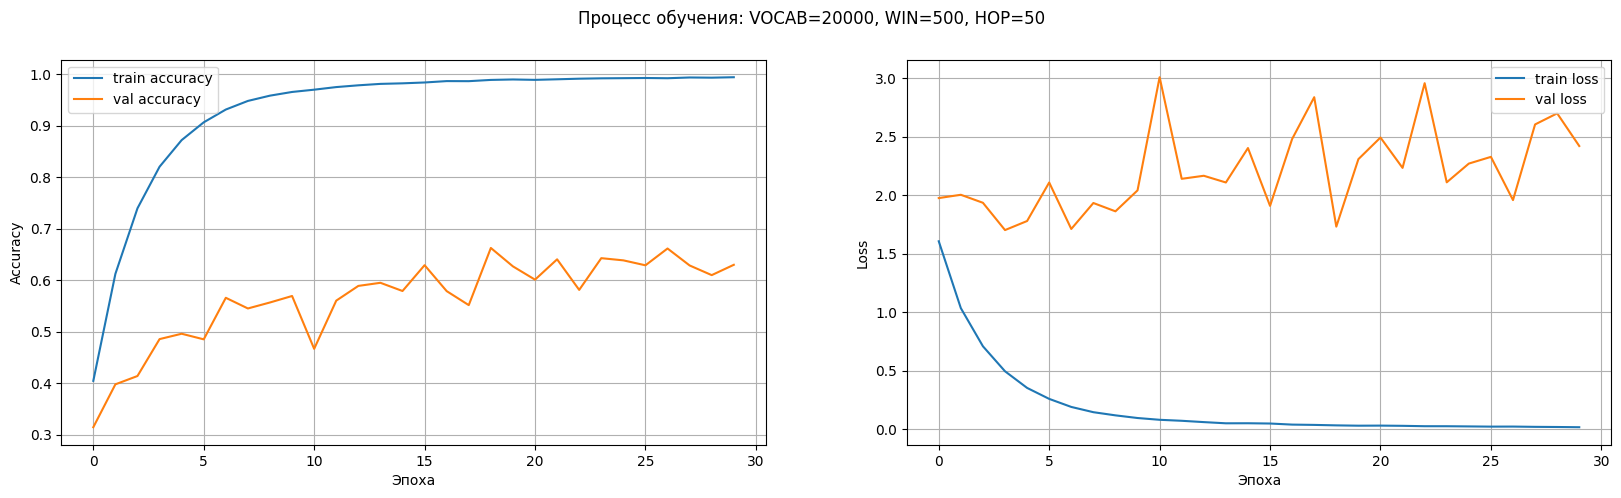

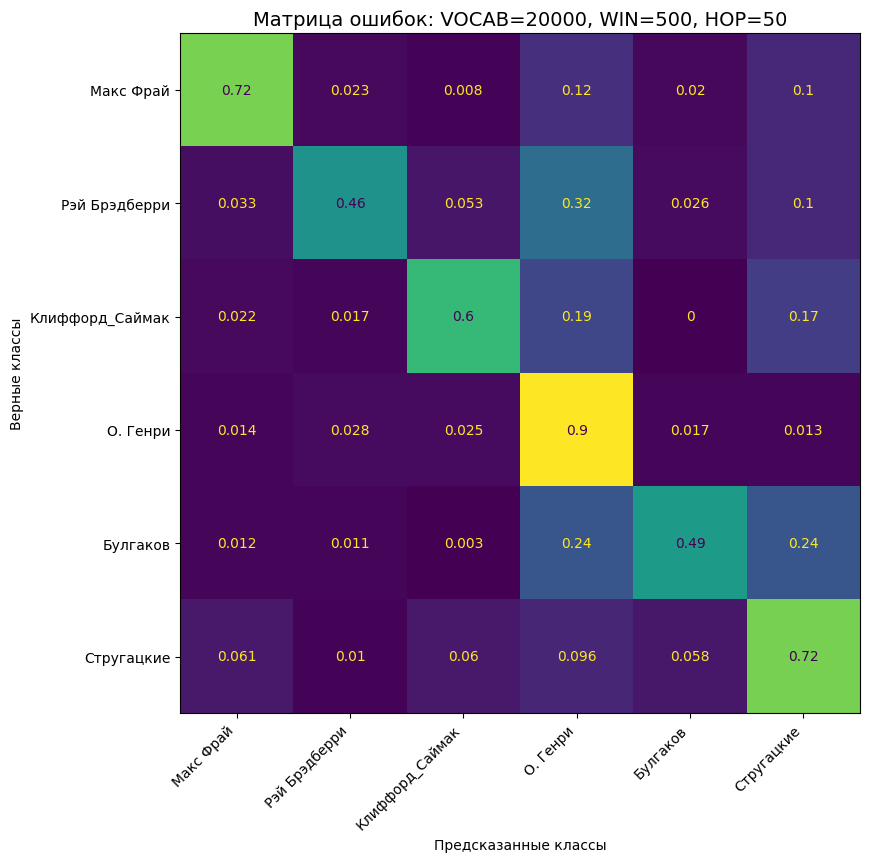


--- Результат "VOCAB=20000, WIN=500, HOP=50" ---
  Класс: Макс Фрай             72% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         46% → Рэй Брэдберри        - ВЕРНО
  Класс: Клиффорд_Саймак       60% → Клиффорд_Саймак      - ВЕРНО
  Класс: О. Генри              90% → О. Генри             - ВЕРНО
  Класс: Булгаков              49% → Булгаков             - ВЕРНО
  Класс: Стругацкие            72% → Стругацкие           - ВЕРНО

Средняя точность распознавания: 65.0%


In [ ]:
#  Эксперимент 5: WIN=500, HOP=50
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=20000, win_size=500, win_hop=50)
torch.manual_seed(SEED)
model = build_best_model(vocab_size=20000, win_size=500)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=20000, WIN=500, HOP=50', epochs=30)
res['vocab'] = 20000; res['win'] = 500; res['hop'] = 50
results.append(res)


VOCAB_SIZE=20000, WIN_SIZE=2000, WIN_HOP=200
x_train: (8792, 2000), x_test: (3314, 2000)
Epoch  1/30 | loss: 2.5312 acc: 0.3558 | val_loss: 3.0390 val_acc: 0.2396
Epoch  2/30 | loss: 0.9345 acc: 0.6979 | val_loss: 2.8539 val_acc: 0.2936
Epoch  3/30 | loss: 0.5412 acc: 0.8074 | val_loss: 3.2882 val_acc: 0.3075
Epoch  4/30 | loss: 0.3575 acc: 0.8770 | val_loss: 3.1491 val_acc: 0.3449
Epoch  5/30 | loss: 0.2876 acc: 0.8977 | val_loss: 3.1508 val_acc: 0.3838
Epoch  6/30 | loss: 0.2197 acc: 0.9215 | val_loss: 3.9430 val_acc: 0.2939
Epoch  7/30 | loss: 0.1807 acc: 0.9328 | val_loss: 3.4823 val_acc: 0.3102
Epoch  8/30 | loss: 0.1528 acc: 0.9439 | val_loss: 3.0662 val_acc: 0.3908
Epoch  9/30 | loss: 0.1371 acc: 0.9520 | val_loss: 3.1227 val_acc: 0.4107
Epoch 10/30 | loss: 0.1318 acc: 0.9563 | val_loss: 3.1146 val_acc: 0.4107
Epoch 11/30 | loss: 0.1181 acc: 0.9586 | val_loss: 3.2966 val_acc: 0.4203
Epoch 12/30 | loss: 0.1064 acc: 0.9620 | val_loss: 4.7403 val_acc: 0.3277
Epoch 13/30 | loss: 0.

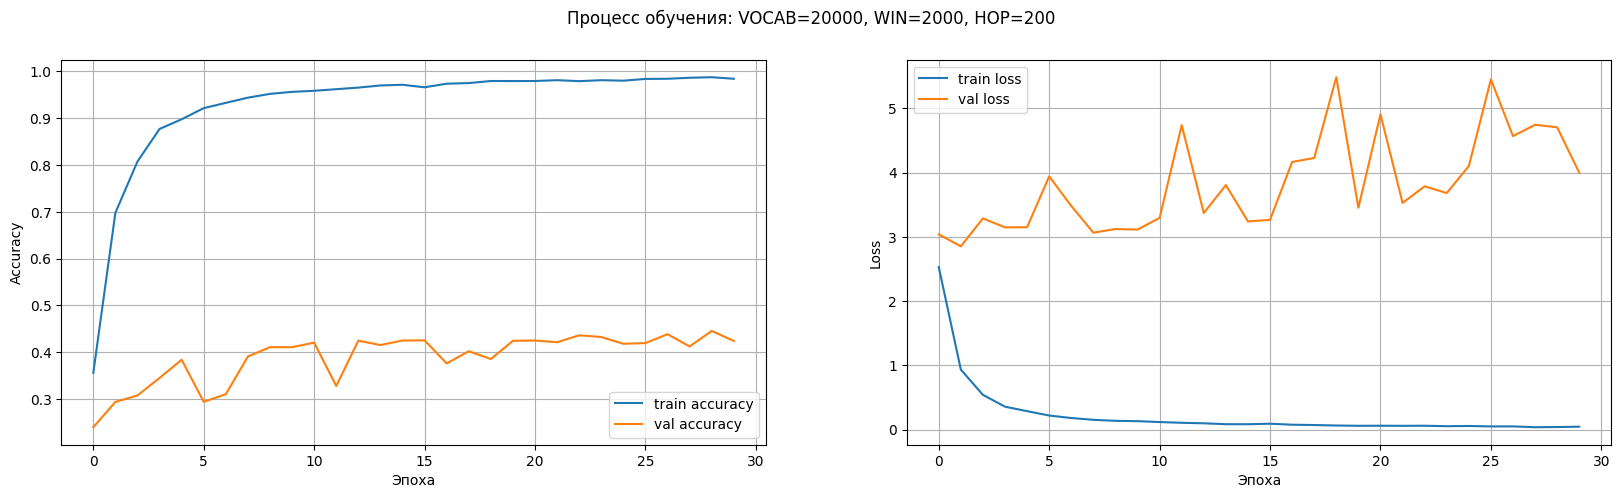

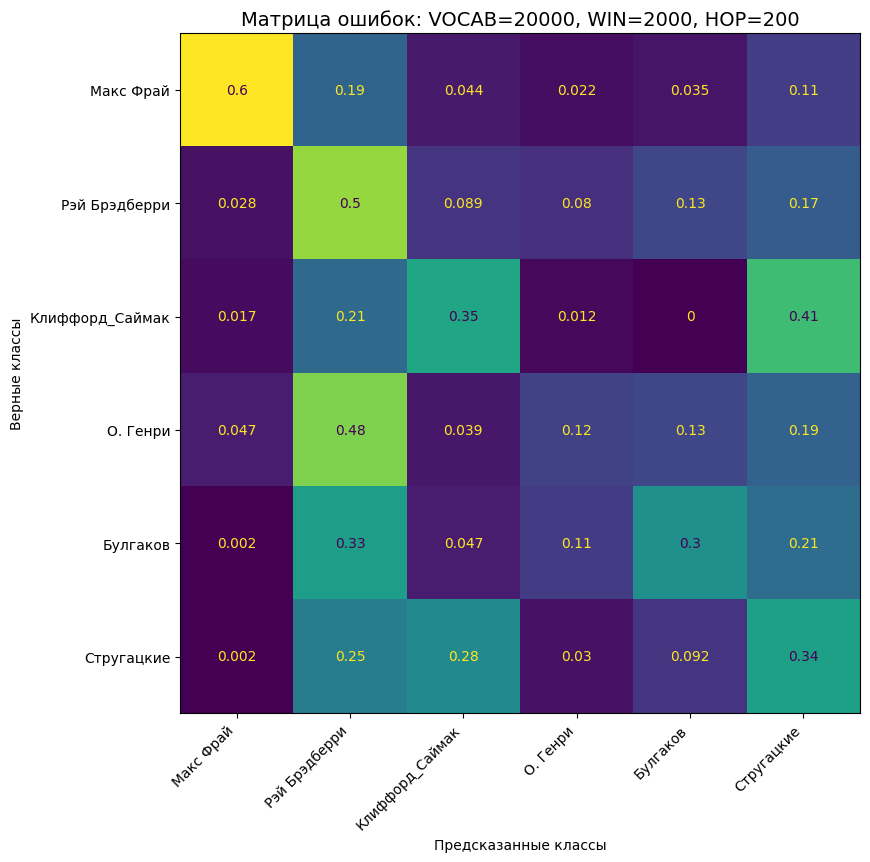


--- Результат "VOCAB=20000, WIN=2000, HOP=200" ---
  Класс: Макс Фрай             60% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         50% → Рэй Брэдберри        - ВЕРНО
  Класс: Клиффорд_Саймак       41% → Стругацкие           - НЕВЕРНО
  Класс: О. Генри              48% → Рэй Брэдберри        - НЕВЕРНО
  Класс: Булгаков              33% → Рэй Брэдберри        - НЕВЕРНО
  Класс: Стругацкие            34% → Стругацкие           - ВЕРНО

Средняя точность распознавания: 36.9%


In [ ]:
#  Эксперимент 6: WIN=2000, HOP=200
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=20000, win_size=2000, win_hop=200)
torch.manual_seed(SEED)
model = build_best_model(vocab_size=20000, win_size=2000)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=20000, WIN=2000, HOP=200', epochs=30)
res['vocab'] = 20000; res['win'] = 2000; res['hop'] = 200
results.append(res)

## 7. Сводная таблица

In [ ]:
import pandas as pd

df = pd.DataFrame(results)
df = df[['vocab', 'win', 'hop', 'mean_acc', 'best_val_acc', 'final_val_acc']]
df.columns = ['VOCAB_SIZE', 'WIN_SIZE', 'WIN_HOP',
              'Средняя точность (по матрице)',
              'Лучшая val_accuracy',
              'Финальная val_accuracy']

# В проценты
for col in ['Средняя точность (по матрице)', 'Лучшая val_accuracy', 'Финальная val_accuracy']:
    df[col] = (df[col] * 100).round(1).astype(str) + '%'

print('СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ')
display(df)

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ


,VOCAB_SIZE,WIN_SIZE,WIN_HOP,Средняя точность (по матрице),Лучшая val_accuracy,Финальная val_accuracy
0,20000,1000,100,53.4%,57.4%,55.1%
1,5000,1000,100,55.2%,58.6%,51.1%
2,10000,1000,100,50.7%,56.4%,54.1%
3,40000,1000,100,44.8%,57.4%,45.0%
4,20000,500,50,65.0%,66.3%,63.0%
5,20000,2000,200,36.9%,44.5%,42.4%
